# CRISP-DM na Prática: Previsão de Churn em Plataforma de Streaming

Notebook para implementar o ciclo de vida de um projeto de Data Science, seguindo a metodologia **CRISP-DM** (Cross-Industry Standard Process for Data Mining).

Utilizaremos um conjunto de dados simulado de uma plataforma de streaming de música para prever quais usuários têm maior probabilidade de cancelar sua assinatura (churn).

## Fase 1: Entendimento do Negócio

Preencha com uma descrição do problema de negócio e como o modelo de previsão pode ser usado para atacar o problema. Explique como o desempenho do modelo influencia as KPIs do negócio.

### 📊 Dicionário de Dados (Churn Dataset)

| Coluna | Descrição |
| :--- | :--- |
| **churn** | Indicador de cancelamento (1 se o cliente cancelou o serviço, 0 caso contrário). |
| **accountweeks** | Número de semanas que o cliente mantém a conta ativa. |
| **ContractRenewal** | Indica se o cliente renovou o contrato recentemente (1 = Sim, 0 = Não). |
| **DataPlan** | Indica se o cliente possui um plano de dados (1 = Sim, 0 = Não). |
| **DataUsage** | Consumo mensal de dados medido em gigabytes (GB). |
| **CustServCalls** | Número de chamadas feitas para o centro de atendimento ao cliente. |
| **DayMins** | Média de minutos de uso durante o dia por mês. |
| **DayCalls** | Média de chamadas realizadas no período diurno. |
| **MonthlyCharge** | Valor médio da fatura mensal do cliente. |
| **OverageFee** | O valor mais alto de taxa por excesso de uso nos últimos 12 meses. |
| **RoamMins** | Média de minutos gastos em roaming (fora da área de cobertura). |

O problema de negócio é identificar a parcela de clientes que obtém um perfil propenso a saída/cancelamento do serviço contratado. Analisando os dados, é possível identificar que podemos aplicar um modelo supervisonado utilizando a coluna de churn como nosso rótulo e as demais como features para treinar o algoritmo a identificar os padrões destes perfis.

Para uma empresa que busca identificar previamente a saída de clientes de sua base, seria interessante utilizar este modelo para agir através de estratégias de marketing visando reter este perímetro.

## Fase 2: Entendimento dos Dados

Nesta fase, exploramos o conjunto de dados para entender sua estrutura, qualidade e distribuição. Buscamos por valores faltantes, tipos de dados inconsistentes e a distribuição das variáveis.

Crie uma conta no Kaggle e baixe o dataset para realizar a Atividade 1: https://www.kaggle.com/datasets/barun2104/telecom-churn


In [1]:
!pip install upsetplot

In [2]:
#importando as bibliotecas
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships
import warnings
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

warnings.filterwarnings(
    "ignore",
    module="upsetplot"
)

In [3]:
!curl -L -o /content/telecom-churn.zip https://www.kaggle.com/api/v1/datasets/download/barun2104/telecom-churn
!unzip /content/telecom-churn.zip -d /content/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 46575  100 46575    0     0    99k      0 --:--:-- --:--:-- --:--:--   99k
Archive:  /content/telecom-churn.zip
replace /content/telecom_churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [4]:
df = pd.read_csv('/content/telecom_churn.csv')

print("Dataset baixado e carregado com sucesso!")

Dataset baixado e carregado com sucesso!


In [90]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


* verificando como os valores estão distribuídos e categorizados nas colunas

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


* Temos:
  * 3333 linhas que podem ser lidas como clientes
  * Todas as colunas apresentam valores preenchidos variando entre os tipos inteiros e reais
  * Algumas colunas estão tratadas de forma numérica mas representam valores categóricos como o SIM ou NÃO (Churn, ContractTRenewal, DataPlan)

In [47]:
# checando a questão dos valores nulos
df.isnull().sum()

,0
Churn,0
AccountWeeks,0
ContractRenewal,0
DataPlan,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0


In [48]:
# verificando os dados das colunas
for i in df.columns:
  if {0,1} in df[i].unique():
    print(f'{i}: {df[i].unique()}')
  else:
    print(f'{i}: {df[i].min(),df[i].max()}')

Churn: (0, 1)
AccountWeeks: (1, 243)
ContractRenewal: (0, 1)
DataPlan: (0, 1)
DataUsage: (0.0, 5.4)
CustServCalls: (0, 9)
DayMins: (0.0, 350.8)
DayCalls: (0, 165)
MonthlyCharge: (14.0, 111.3)
OverageFee: (0.0, 18.19)
RoamMins: (0.0, 20.0)


In [49]:
# verificando se existem valores duplicados
df.duplicated().sum()

np.int64(0)

In [50]:
# verificando as informações estatísticas
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


É possível observar que há uma diferença em relação ao intervalo encontrado nas features. Isso indica a necessidade de normalização.

* Analisando a distribuição dos dados

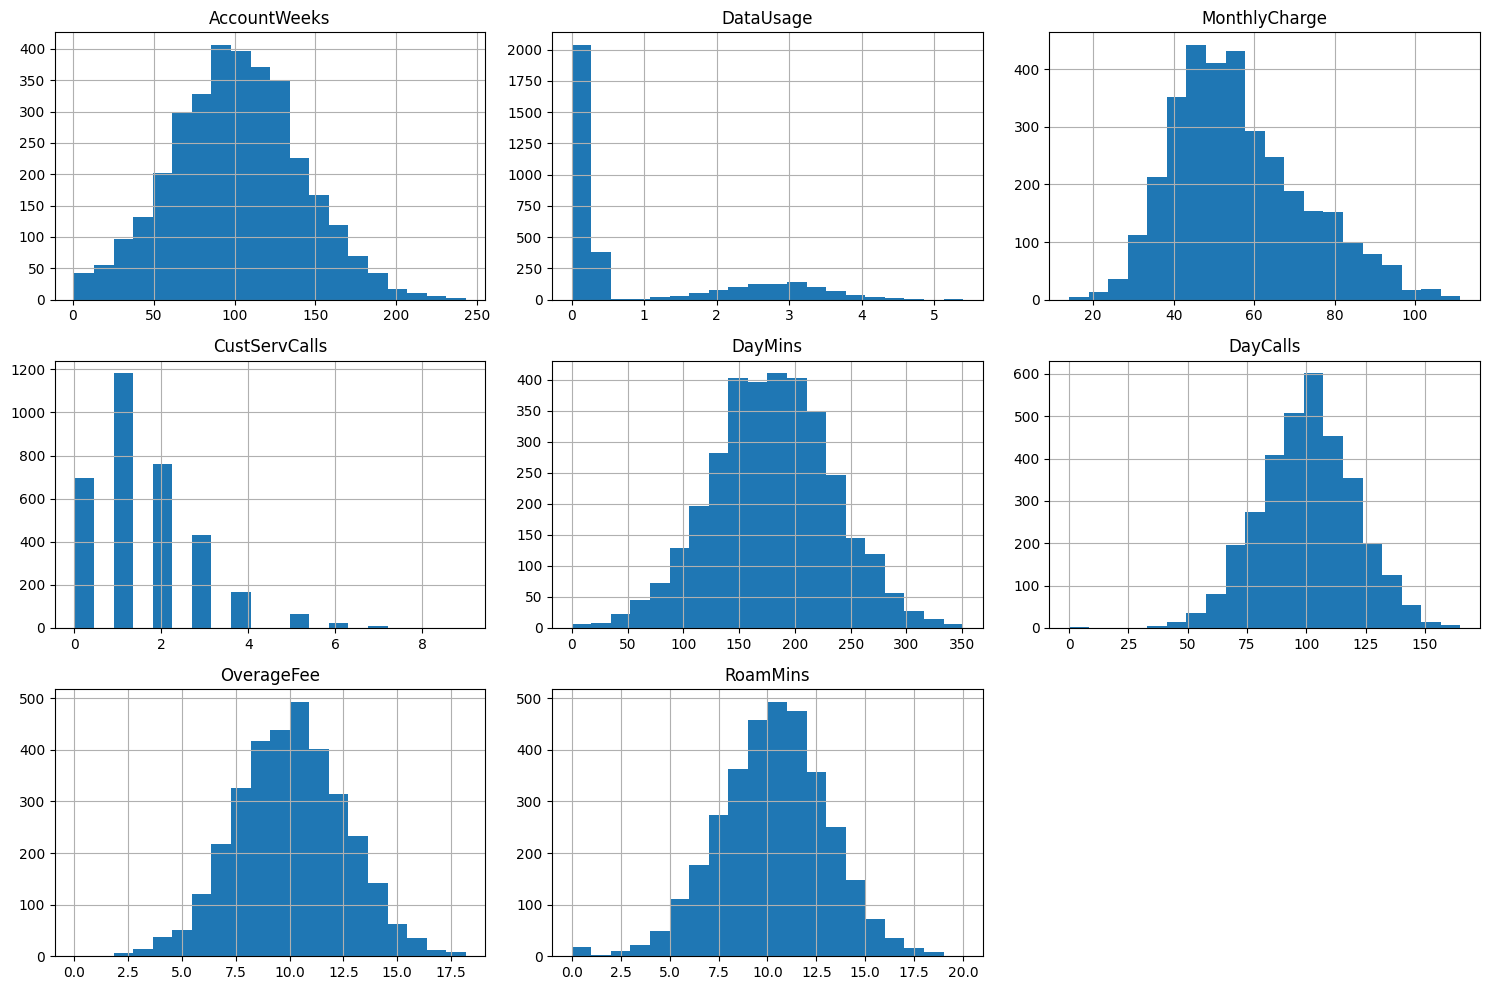

In [51]:
df_dist = df[['AccountWeeks','DataUsage','MonthlyCharge','CustServCalls','DayMins','DayCalls','OverageFee','RoamMins']].copy()
df_dist.hist(bins=20, figsize=(15, 10), layout=(3, 3), grid=True)
plt.tight_layout()
plt.show()

Observações:
  1. Podemos observar que a maioria dos dados apresentam uma distribuição aproximadamente normal. Isto indica que iremos padronizá-los.
  2. Para a feature de data usage vemos que a quantidade de dados utilizados se concentra mais no intervalo de 0 a 0.5 GB. Ou seja, não há tanto uso de dados nestes clientes podendo ser uma parcela a ser investigada.

* Analisando o perfil do usuário sobre o churn

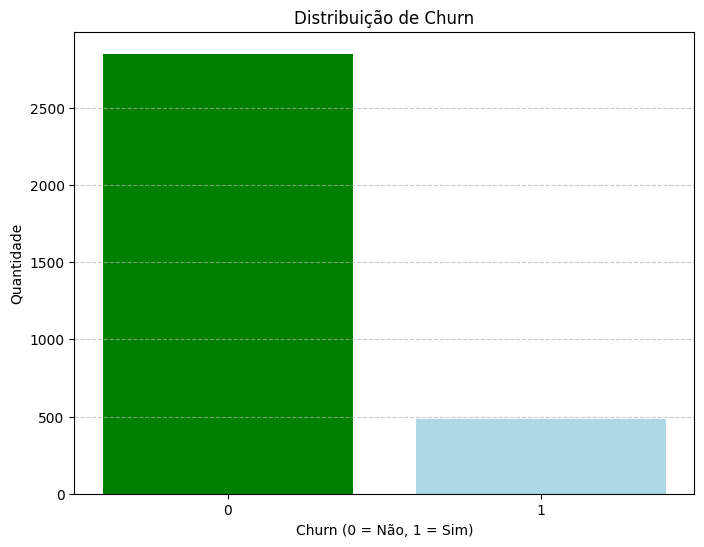

In [52]:
df_vis_churn = df['Churn'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(df_vis_churn.index.astype(str), df_vis_churn.values, color=['green', 'lightblue'])

plt.title('Distribuição de Churn')
plt.xlabel('Churn (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Existem muitos mais casos sem churn. Ou seja, os dados estão desbalanceados e irá influenciar no treinamento do modelo.

In [53]:
# Grupo de pessoas a partir da renovação de contrato recente
df_vis_churn = df.groupby(['ContractRenewal','Churn'])['Churn'].count()
df_vis_churn

ContractRenewal  Churn
0                0         186
                 1         137
1                0        2664
                 1         346
Name: Churn, dtype: int64

A quantidade de pessoas que fizeram uma renovação recente e efetuaram o churn é bem maior do que as pessoas que não renovaram recentemente. Isto pode indicar que talvez após a renovação possa ter ocorrido algum fator que influenciou a saída, por exemplo, o aumento da fatura.

In [54]:
# Grupo de pessoas com plano de dados
df_vis_churn = df.groupby(['DataPlan','Churn'])['Churn'].count()
df_vis_churn

DataPlan  Churn
0         0        2008
          1         403
1         0         842
          1          80
Name: Churn, dtype: int64

As pessoas sem plano de dados efetuam mais o churn do que as pessoas com plano de dados. Ou seja, indica que talvez a medida que o uso de dados vá aumentando e não há um plano que cubra este consumo, o que está relacionado a fatura ou disponibilidade dos dados, as pessoas vão efetuando a saída da base.

In [55]:
# Analisando as classificações de renovação de contrato, plano de dados e churn ao mesmo tempo

# dataplan -> 0 = não, 1 = sim
# contractrenewal -> 0 = não, 1 = sim
# churn -> 0 = não, 1 = sim

df_vis_churn = df.groupby(['ContractRenewal','DataPlan','Churn'])['Churn'].count()
df_vis_churn

ContractRenewal  DataPlan  Churn
0                0         0         130
                           1         101
                 1         0          56
                           1          36
1                0         0        1878
                           1         302
                 1         0         786
                           1          44
Name: Churn, dtype: int64

Analisando a intersecção entre os conjuntos de renovação de contrato, churn e plano de dados

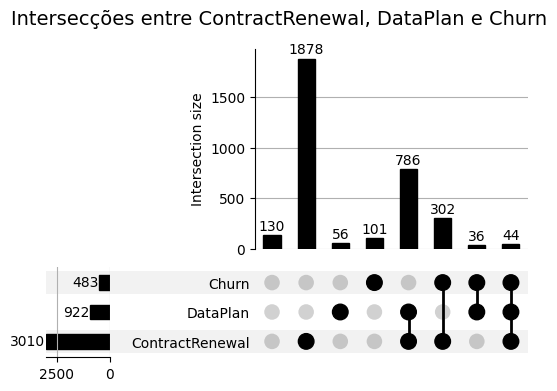

In [56]:
df_vis_churn = (
    df
    .groupby(['ContractRenewal', 'DataPlan', 'Churn'])
    .size()
    .reset_index(name='count')
)

memberships = []
counts = []

for _, row in df_vis_churn.iterrows():
    m = []

    if row['ContractRenewal'] == 1:
        m.append('ContractRenewal')

    if row['DataPlan'] == 1:
        m.append('DataPlan')

    if row['Churn'] == 1:
        m.append('Churn')

    memberships.append(m)
    counts.append(row['count'])


upset_data = from_memberships(
    memberships,
    data=counts
)


UpSet(
    upset_data,
    subset_size='sum',
    show_counts=True,
    sort_by='degree'
).plot()

plt.suptitle(
    'Intersecções entre ContractRenewal, DataPlan e Churn',
    fontsize=14
)

plt.show()


A maioria da base renovou o contrato (3010 clientes)

Mesmo renovando contrato:

  * 302 efetuaram o churn sem plano de dados
  * 44 efetuaram o churn mesmo com plano de dados. O que chama atenção, pois este grupo, teoricamente, já recebeu dois incentivos de retenção mas mesmo assim saiu do contrato.

Clientes sem renovação têm churn relativamente alto (101 + 36)

* Analises complementares

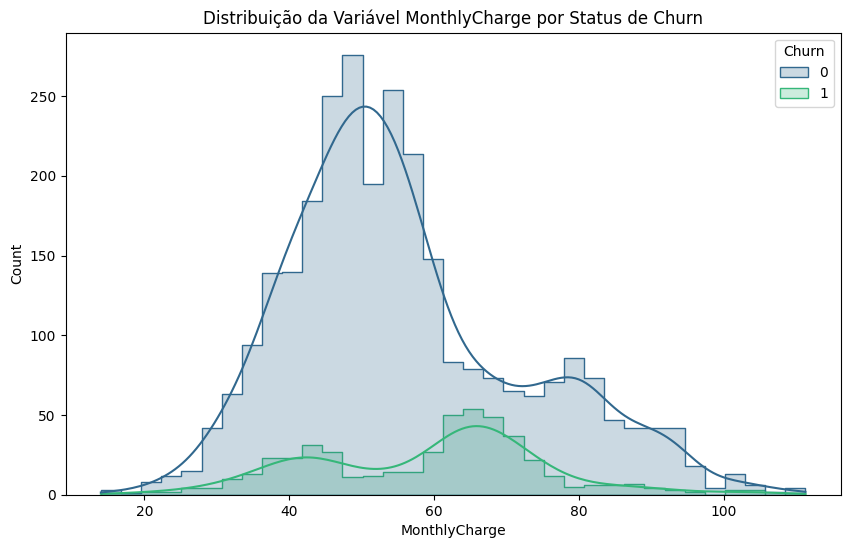

In [57]:
# Analisando a hipótese se o valor da fatura tem algum impacto no churn
plt.figure(figsize=(10, 6))
# O parâmetro 'hue' faz todo o trabalho de separar 0 de 1
sns.histplot(data=df, x='MonthlyCharge', hue='Churn', kde=True, element="step", palette='viridis')
plt.title('Distribuição da Variável MonthlyCharge por Status de Churn')
plt.show()

Temos uma concentração maior de churn no intervalo de fatura entre 60 a 80. Algo que não é visto se compararmos com o grupo sem churn que se concentra entre 40 a 60 em termos de fatura.

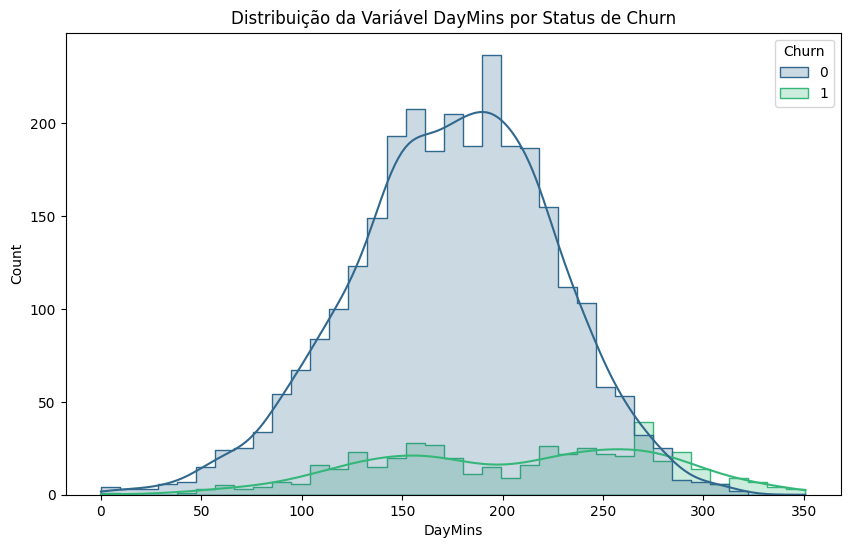

In [58]:
# Verificando a relação do uso de minutos
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='DayMins', hue='Churn', kde=True, element="step", palette='viridis')
plt.title('Distribuição da Variável DayMins por Status de Churn')
plt.show()

É possível observar que há uma concentração maior em relação a média de minutos dos clientes que efetuaram churn nos valores acima de 200.

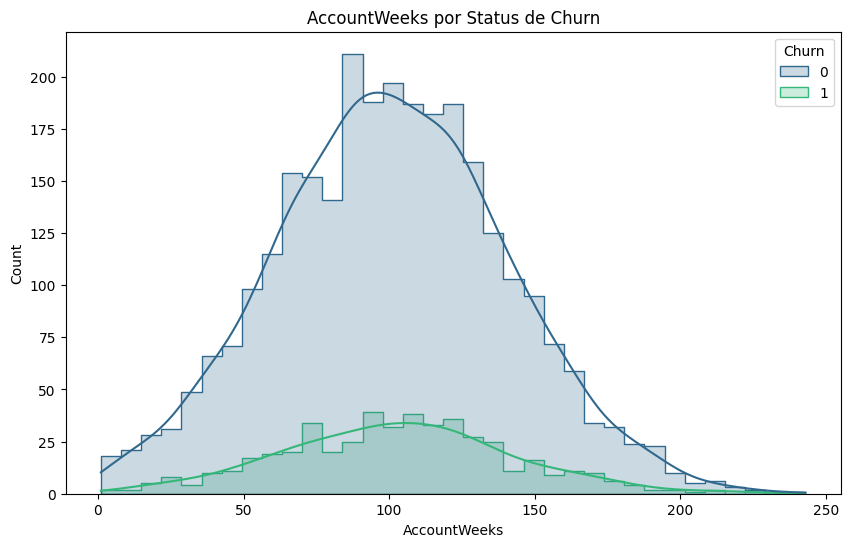

In [59]:
# Verificando a relação da quantidade de semanas ativas e o churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='AccountWeeks', hue='Churn', kde=True, element="step", palette='viridis')
plt.title('AccountWeeks por Status de Churn')
plt.show()

Os usuários que efetuam churn estão concentrados no intervalo de 50 a 150 semanas ativas.

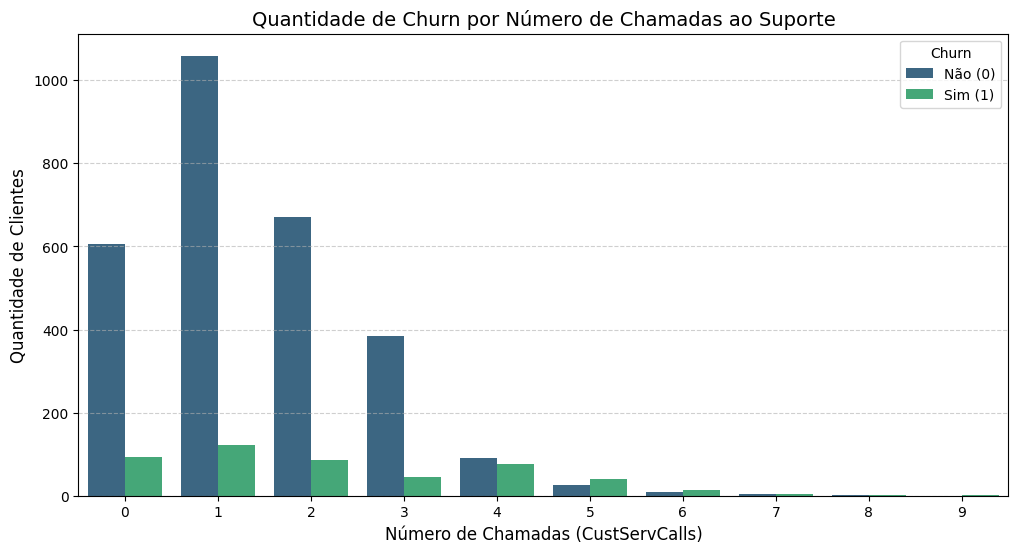

In [60]:
# Analisando a quantidade de chamadas efetuadas ao suporte e o status de churn
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='CustServCalls', hue='Churn', palette='viridis')

plt.title('Quantidade de Churn por Número de Chamadas ao Suporte', fontsize=14)
plt.xlabel('Número de Chamadas (CustServCalls)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
plt.legend(title='Churn', labels=['Não (0)', 'Sim (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

As pessoas que realizam o cancelamento efetuam mais ligações acima de 4 vezes. Talvez, elas não estão conseguindo solucionar algum tipo de problema e por ter tentado mais de 4 vezes resolvem desistir do contrato.

## Fase 3: Preparação dos Dados

Agora, preparamos os dados para a modelagem. Isso inclui a limpeza de dados, a transformação de variáveis e a criação de novas features (Engenharia de Features) para treinar o modelo.

A saída deve ser um novo arquivo CSV para treinamento do modelo.

* Correlação e Padronização dos dados

In [5]:
# padronização dos dados (apenas nas colunas do tipo float)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Identifique suas colunas
cols_float = ['AccountWeeks','DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee','RoamMins'] # Colunas contínuas
cols_binarias = ['Churn', 'ContractRenewal','DataPlan'] # Colunas 0 e 1

# Criar o transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_float)
    ],
    remainder='passthrough' # não altera as colunas binárias
)

# Aplicar ao DataFrame
df_processado = preprocessor.fit_transform(df)

# 2. Recupera os nomes das colunas na ordem correta
# O sklearn mantém a ordem: (colunas transformadas + colunas do passthrough)
colunas_finais = preprocessor.get_feature_names_out()

colunas_finais = [i.replace('num__','').replace('remainder__','') for i in colunas_finais]

# 3. Cria o novo DataFrame usando o índice do original
df_padronizado  = pd.DataFrame(df_processado, columns=colunas_finais, index=df.index)

In [6]:
df_padronizado.head()

,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,Churn,ContractRenewal,DataPlan
0,0.676489,1.480204,-0.427932,1.566767,0.476643,1.990727,-0.071584,-0.085008,0.0,1.0,1.0
1,0.149065,2.266072,-0.427932,-0.333738,1.124503,1.564510,-0.107082,1.240482,0.0,1.0,1.0
2,0.902529,-0.641642,-1.188218,1.168304,0.675985,-0.262133,-1.574346,0.703121,0.0,1.0,0.0
3,-0.428590,-0.641642,0.332354,2.196596,-1.466936,0.042307,-2.741846,-1.303026,0.0,0.0,0.0
4,-0.654629,-0.641642,1.092641,-0.240090,0.626149,-0.931902,-1.037927,-0.049184,0.0,0.0,0.0


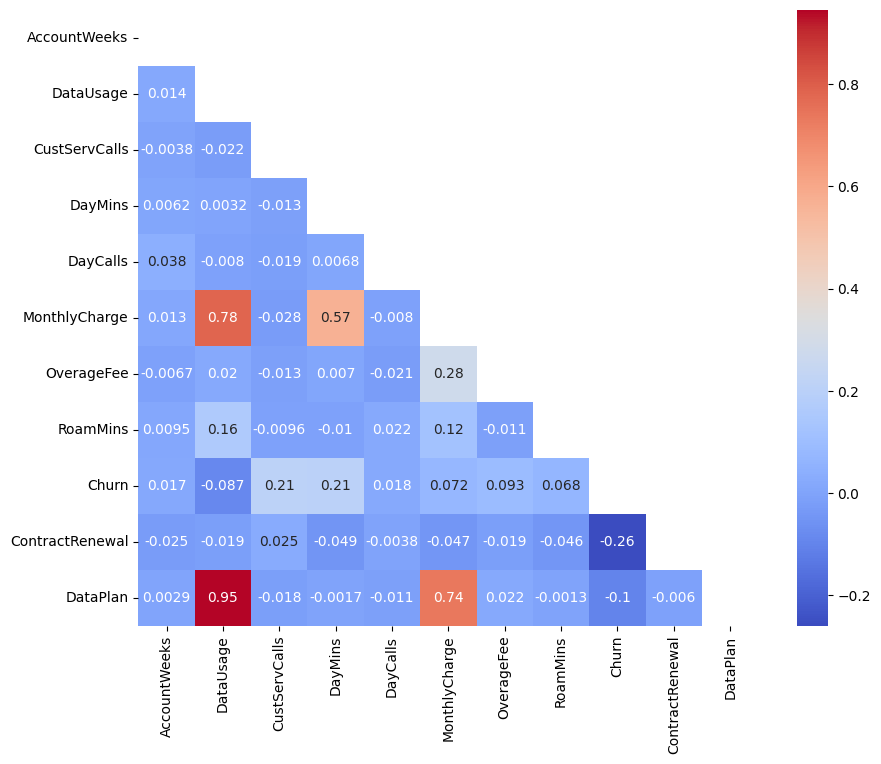

In [7]:
# verificando a correlação entre os dados
plt.figure(figsize=(10, 8))
corr = df_padronizado.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.show()

Temos colunas que apresentam uma correlação positiva entre si:
* Datausage e Dataplan
* MonthlyCharge com Dataplan
* MonthlyCharge com Datausage
* MonthlyCharge com DayMins

Isto nos indica, por exemplo, que a feature MonthlyCharge aumenta a medida que a média de minutos aumenta (o que é esperado). Assim como, a medida que a quantidade de dados utilizados aumenta temos uma cobrança proporcional na fatura.

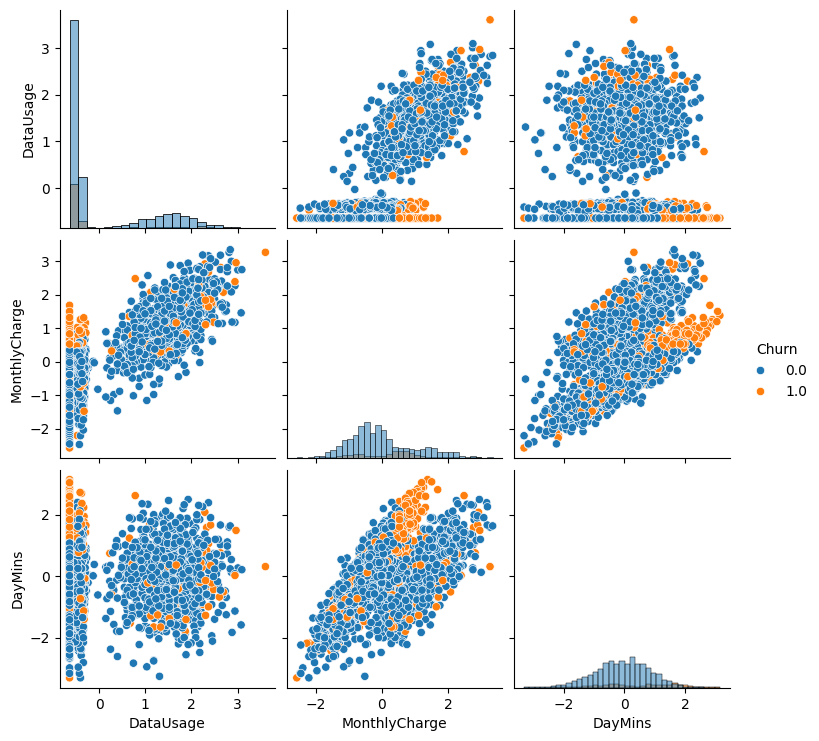

In [93]:
sns.pairplot(df_padronizado[['DataUsage','MonthlyCharge','DayMins','Churn']], hue = 'Churn', diag_kind="hist")
plt.show()

Nesta distribuição, é possível observar que existe uma parcela de clientes que efetuaram o cancelamento alta a medida que a fatura aumentou e seu consumo de minutos também.

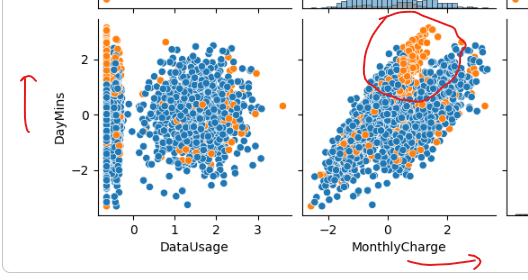

### Resumo da exploração e preparação dos dados

1. Temos dados desbalanceados, sendo necessário utilizar alguma estratégia de balanceamento para treinar um modelo.
2. A maioria das features contínuas apresentam uma distribuição aproximadamente normal nos indicando que a padronização é o mais apropriado de ser aplicada.
3. É possível perceber alguns fatores que podem influenciar no churn, sendo eles:
    * aumento de fatura a medida que a média do uso diário de minutos aumenta.
    * quantidade de ligações para o suporte acima de 4 vezes
    * efetuação da renovação do contrato, aonde existe uma quantidade maior de churn após este processo.
    * a não contratação de um plano de dados concentra a maior quantidade de clientes com churn
    * O intervalo de semanas com a conta ativa para o clientes com churn se concentram entre 50 a 150.
4. Como processo de entendimento do negócio poderia sugerir concentrar os esforços em estratégias de retenção para usuários que:
  * não tem plano de dados e obtém uma renovação recente de contrato
  * não tem plano de dados e não renovou o contrato

* Exportando os dados tratados para as próximas etapas do CRISP-DM

In [ ]:
#df_padronizado.to_csv('df_padronizado.csv', index=False)

## Fase 4: Modelagem

In [8]:
# separação do conjunto de treino, validação e teste

X, y = df_padronizado.drop('Churn',axis=1), df_padronizado['Churn'] # separando as features e o target

# treino e teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#X_temp, X_test, y_temp, y_test -> vão pegar o dado original e separar em 80% pra treino e 20% pra teste

# treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

# A partir dos dados originais separados para treino vamos criar o conjunto de validação. Ou seja, dos 80% separado
# para treino, vamos separá-lo em 75% para treino e 25% para validação.


In [9]:
# vamos utilizar uma técnica de oversampling para separarmos as variáveis de treino e teste de forma balanceada

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print(sorted(Counter(y_resampled).items()))

[(0.0, 1710), (1.0, 1710)]


### Aplicando os modelos

* XGboost
* Regressão logística

Xgboost

In [10]:
# XGboost

from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    scale_pos_weight=1,  # após oversampling
    eval_metric='logloss'
)


In [11]:
# treinando o modelo

xgboost_model.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Analisando a importância das features no treinamento do modelo

In [12]:
importances = xgboost_model.feature_importances_

df_importances = pd.DataFrame({
    'feature': X_resampled.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

df_importances

,feature,importance
8,ContractRenewal,0.355623
2,CustServCalls,0.179718
3,DayMins,0.110370
1,DataUsage,0.089637
5,MonthlyCharge,0.085636
6,OverageFee,0.051203
7,RoamMins,0.046620
0,AccountWeeks,0.045512
4,DayCalls,0.035681
9,DataPlan,0.000000


Como visto, algumas features obtém zero ou pouquíssima relevância para o treinamento do modelo. Logo, vou retreinar deixando apenas aquelas acima do limite de 0.05.

In [13]:
X_fi, y_fi = df_padronizado.drop(['Churn','DataPlan','DayCalls','AccountWeeks','RoamMins'],axis=1), df_padronizado['Churn'] # separando as features e o target

# treino e validação
X_temp_fi, X_test_fi, y_temp_fi, y_test_fi = train_test_split(
    X_fi, y_fi, test_size=0.2, stratify=y, random_state=42
)

#X_temp, X_test, y_temp, y_test -> vão pegar o dado original e separar em 80% pra treino e 20% pra teste

# treino e validação
X_train_fi, X_val_fi, y_train_fi, y_val_fi = train_test_split(
    X_temp_fi, y_temp_fi, test_size=0.25, stratify=y_temp, random_state=42
)

# balanceando os dados
ros_fi = RandomOverSampler(random_state=42)
X_resampled_fi, y_resampled_fi = ros_fi.fit_resample(X_train_fi, y_train_fi)

xgboost_model_fi = XGBClassifier(
    scale_pos_weight=1,  # após oversampling
    eval_metric='logloss'
)


# aplicando o modelo
xgboost_model_fi.fit(X_resampled_fi, y_resampled_fi)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Regressão Logística

In [14]:
# Regressão Logística

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)


In [15]:
# treinando o modelo
lr_model.fit(X_resampled, y_resampled)

LogisticRegression(max_iter=1000)

## Fase 5: Avaliação

In [16]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def avaliar_modelo(model, X_val, y_val, nome):
    y_prob = model.predict_proba(X_val)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'\n {nome}')
    print('ROC AUC:', roc_auc_score(y_val, y_prob))
    print('PR AUC:', average_precision_score(y_val, y_prob))
    print(classification_report(y_val, y_pred, digits=4))


In [22]:
avaliar_modelo(lr_model, X_val, y_val, 'Logistic Regression')
avaliar_modelo(xgboost_model, X_val, y_val, 'XGBoost sem Feature Importance')
avaliar_modelo(xgboost_model_fi, X_val_fi, y_val_fi, 'XGBoost com Feature Importance')


 Logistic Regression
ROC AUC: 0.8343823476216315
PR AUC: 0.4824694959909689
              precision    recall  f1-score   support

         0.0     0.9566    0.7737    0.8555       570
         1.0     0.3738    0.7938    0.5083        97

    accuracy                         0.7766       667
   macro avg     0.6652    0.7837    0.6819       667
weighted avg     0.8719    0.7766    0.8050       667


 XGBoost sem Feature Importance
ROC AUC: 0.8987701211792367
PR AUC: 0.8040591499729777
              precision    recall  f1-score   support

         0.0     0.9531    0.9632    0.9581       570
         1.0     0.7692    0.7216    0.7447        97

    accuracy                         0.9280       667
   macro avg     0.8612    0.8424    0.8514       667
weighted avg     0.9264    0.9280    0.9271       667


 XGBoost com Feature Importance
ROC AUC: 0.8976668475311992
PR AUC: 0.7598328703778374
              precision    recall  f1-score   support

         0.0     0.9459    0.9509    0

Observamos que o modelo de XGboost sen a feature importance obtém um melhor desempenho do que o de Regressão logística em relação as métricas de Acurácia, Precision e Recall. Abaixo vamos analisar a curva ROC.

**Curva ROC**

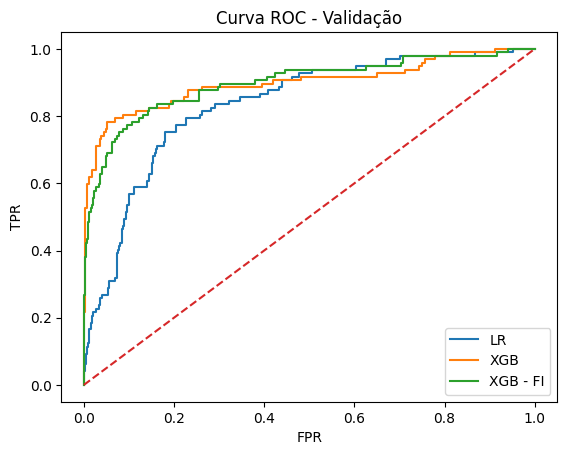

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

models = {'LR': lr_model, 'XGB': xgboost_model, 'XGB - FI': xgboost_model_fi}

for name, model in models.items():
  if name == "LR" or name == "XGB":
      y_prob = model.predict_proba(X_val)[:,1]
      fpr, tpr, _ = roc_curve(y_val, y_prob)
  else:
      y_prob = model.predict_proba(X_val_fi)[:,1]
      fpr, tpr, _ = roc_curve(y_val_fi, y_prob)

  plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], '--')
plt.legend()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC - Validação')
plt.show()



XGBoost apresenta o melhor desempenho, sendo assim para poucos falsos positivos, o XGBoost já captura muitos churns. A regressão logística precisa “errar mais” para alcançar o mesmo recall.

## Fase 6: Implantação

In [18]:
X_val

,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,ContractRenewal,DataPlan
2930,0.576028,-0.641642,-0.427932,-0.346591,0.426808,-0.992790,-1.120756,0.953889,1.0,0.0
2769,0.902529,-0.460892,-0.427932,-0.445748,-0.968582,-0.974524,-1.337690,-0.407425,1.0,0.0
917,-0.729976,-0.641642,-1.188218,-1.297762,-0.171217,-1.662560,-1.680841,-0.694017,1.0,0.0
2145,0.098834,-0.382305,-0.427932,0.255694,0.376972,-0.243867,-0.351626,0.201584,1.0,0.0
1187,1.028106,0.607889,0.332354,0.747805,-0.320723,1.071317,0.760655,-1.553794,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
373,-1.734594,-0.641642,0.332354,-0.274978,-0.121381,-0.505686,0.571330,1.634546,1.0,0.0
2046,0.475566,-0.641642,-0.427932,-0.561431,-0.121381,-0.871014,-0.146524,0.309056,1.0,0.0
1988,-1.056476,-0.311577,-0.427932,-0.543069,-1.516771,-0.615284,-0.300351,0.667297,1.0,0.0
2044,-0.529052,1.480204,-1.188218,0.081252,1.573021,1.016517,-0.659278,-0.085008,0.0,1.0


In [19]:
# analisando a faixa de risco do score

y_val_prob = xgboost_model.predict_proba(X_val)[:, 1] # selecionando no array da probabilidade apenas os casos com churn

df_val = X_val.copy()
df_val['y_true'] = y_val.values # selecionando a variável de churn para o dataset de validação
df_val['prob_churn'] = y_val_prob # valores previstos a partir do treinamento do modelo

df_val['risk_band'] = pd.qcut(
    df_val['prob_churn'],
    q=[0, 0.33, 0.66, 1.0], # faixa de risco
    labels=['Baixo', 'Médio', 'Alto']
)


In [20]:
df_val.head()

,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,ContractRenewal,DataPlan,y_true,prob_churn,risk_band
2930,0.576028,-0.641642,-0.427932,-0.346591,0.426808,-0.992790,-1.120756,0.953889,1.0,0.0,0.0,0.000128,Baixo
2769,0.902529,-0.460892,-0.427932,-0.445748,-0.968582,-0.974524,-1.337690,-0.407425,1.0,0.0,0.0,0.000407,Baixo
917,-0.729976,-0.641642,-1.188218,-1.297762,-0.171217,-1.662560,-1.680841,-0.694017,1.0,0.0,0.0,0.005222,Médio
2145,0.098834,-0.382305,-0.427932,0.255694,0.376972,-0.243867,-0.351626,0.201584,1.0,0.0,0.0,0.002971,Médio
1187,1.028106,0.607889,0.332354,0.747805,-0.320723,1.071317,0.760655,-1.553794,1.0,1.0,0.0,0.001497,Baixo


In [21]:
summary = (
    df_val
    .groupby('risk_band')
    .agg(
        clientes=('y_true', 'count'),
        churn_rate=('y_true', 'mean')
    )
    .reset_index()
)

summary


/tmp/ipython-input-485496518.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('risk_band')


,risk_band,clientes,churn_rate
0,Baixo,220,0.036364
1,Médio,220,0.018182
2,Alto,227,0.374449


Este resultado nos indica que o modelo consegue identificar bem a parcela do churn para aqueles como risco alto. Então, numa ação de retenção conseguiríamos atingir uma boa parcela. Contudo, considerando a faixa baixa e média ele não consegue distinguir muito bem os dois grupos.